# Metabolite–Target Pair Analysis for Cancer Cell-Cell Communication

**File**: `human_database_merge_unique_metab_target_pairs_with_HMDB_Info.csv`  
**Goal**: Profile the interaction network, identify cancer-relevant hubs, characterize interaction biology, and prioritize pairs for downstream single-cell RNA-sequencing (scRNAseq) and TCGA clinical integration.

---
## 1. Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (12,6), 'font.size': 12, 'axes.titlesize': 16, 'axes.labelsize': 14})

In [5]:
# ==========================================
# ⚙️ USER PARAMETERS (Confidence Filter & Export Options)
# ==========================================
# Choose which metabolite confidence tiers to retain for downstream analysis:
# - 'all'            -> Retain all target pairs (Tiers 1, 2, and 3)
# - 'tier_1'         -> Retain only Tier 1 (High Confidence) pairs (4+ databases)
# - 'tier_1_and_2'   -> Retain Tier 1 and Tier 2 (High & Medium Confidence) pairs
TIER_FILTER = 'all'  # DEFAULT: 'all'. Change to 'tier_1' or 'tier_1_and_2' to filter!

# Full Notebook HTML Report Export Toggle:
# - True  -> Automatically exports the entire notebook (Markdown, Code, Tables, Figures) to styled HTML
# - False -> Disables automatic HTML export
SAVE_AS_HTML = True  # DEFAULT: False. Change to True to export the entire notebook!

## 2. Load Data

### Purpose
To ingest the consolidated metabolite-target interaction pair database, which has been simplified and enriched with HMDB annotation metadata. Loading this data enables structural and functional network analysis across all integrated databases (Celllinker2, MRCLinkDB, MEBOCOST, and CellPhoneDBv5).

### How to Interpret the Output
- **Interaction Pairs count:** Indicates the size and complexity of the metabolic interactome.
- **Unique Metabolites & Targets count:** Reveals the diversity of the metabolic signals (ligands) and their corresponding molecular receptors/sensors in the TME.
- **DataFrame Preview:** Review the column headers to verify successful mapping of chemical identifiers (e.g., SMILES, AVERAGE_MASS), provenance databases, and clinical metadata.

In [6]:
df = pd.read_csv('../output/human_database_merge_unique_metab_target_pairs_with_HMDB_Info.csv', low_memory=False)
print(f'Loaded {len(df):,} interaction pairs | {df["HMDB_ID"].nunique()} unique HMDB metabolites ({df["Metabolite_Name"].nunique()} names) | {df["Target"].nunique()} targets | {df.shape[1]} columns')

# ==========================================
# ⚙️ CONFIDENCE TIER MAPPING & FILTERING
# ==========================================
print("\nAssigning and mapping confidence tiers...")

# 1. Assign Pair Confidence Tier
def assign_tier(row):
    score = row['databases_count']
    has_smiles = pd.notna(row['SMILES'])
    has_mass = pd.notna(row['AVERAGE_MASS'])
    if score >= 4 and has_smiles and has_mass:
        return 'Tier 1 (High)'
    elif score >= 2 and has_smiles:
        return 'Tier 2 (Medium)'
    else:
        return 'Tier 3 (Low)'

df['Pair_Confidence_Tier'] = df.apply(assign_tier, axis=1)
df['Confidence_Tier'] = df['Pair_Confidence_Tier']  # Keep as alias for backward compatibility

# 2. Map Metabolite Confidence Tier from the unique metabolite dataset
try:
    df_metab_ref = pd.read_csv('../output/human_database_merge_unique_metab_with_HMDB_Info.csv', low_memory=False)
    df_metab_ref['Metabolite_Confidence_Tier'] = df_metab_ref.apply(assign_tier, axis=1)
    
    # Create mapping dictionaries
    hmdb_tier_map = dict(zip(
        df_metab_ref['HMDB_ID'].astype(str).str.strip(),
        df_metab_ref['Metabolite_Confidence_Tier']
    ))
    name_tier_map = dict(zip(
        df_metab_ref['Metabolite_Name'].astype(str).str.lower().str.strip(),
        df_metab_ref['Metabolite_Confidence_Tier']
    ))
    
    # Apply hybrid mapping
    df['clean_hmdb'] = df['HMDB_ID'].astype(str).str.split(',').str[0].str.strip()
    df['clean_name'] = df['Metabolite_Name'].astype(str).str.lower().str.strip()
    
    tier_by_hmdb = df['clean_hmdb'].map(hmdb_tier_map)
    tier_by_name = df['clean_name'].map(name_tier_map)
    
    df['Metabolite_Confidence_Tier'] = tier_by_hmdb.fillna(tier_by_name)
    df['Metabolite_Confidence_Tier'] = df['Metabolite_Confidence_Tier'].fillna('Tier 3 (Low)')
    
    # Drop temp columns
    df = df.drop(columns=['clean_hmdb', 'clean_name'])
except Exception as e:
    print(f"⚠️ Warning: Could not map Metabolite Confidence Tiers: {e}")
    df['Metabolite_Confidence_Tier'] = 'Tier 3 (Low)'

# Apply filter based on TIER_FILTER parameter
if TIER_FILTER == 'tier_1':
    allowed_tiers = ['Tier 1 (High)']
elif TIER_FILTER == 'tier_1_and_2':
    allowed_tiers = ['Tier 1 (High)', 'Tier 2 (Medium)']
else:
    allowed_tiers = ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']

initial_count = len(df)
df = df[df['Confidence_Tier'].isin(allowed_tiers)].copy()
filtered_count = len(df)

print(f"✅ Confidence Tier Filter Applied: Retained {allowed_tiers}")
print(f"   -> Original pairs: {initial_count:,}")
print(f"   -> Retained pairs: {filtered_count:,} ({filtered_count/initial_count*100:.1f}%)")
print(f"   -> Unique HMDB metabolites remaining: {df['HMDB_ID'].nunique():,} ({df['Metabolite_Name'].nunique():,} names)")
print(f"   -> Unique targets remaining: {df['Target'].nunique():,}\n")

# Print remaining breakdown
print("Breakdown of remaining interaction pairs (Pair Confidence):")
for tier, count in df['Pair_Confidence_Tier'].value_counts().items():
    print(f"  * {tier}: {count:,} pairs")

print("\nBreakdown of remaining interaction pairs (Metabolite Confidence):")
for tier, count in df['Metabolite_Confidence_Tier'].value_counts().items():
    print(f"  * {tier}: {count:,} pairs")

df.head()

Loaded 8,596 interaction pairs | 401 unique HMDB metabolites (398 names) | 2007 targets | 92 columns

Assigning and mapping confidence tiers...
✅ Confidence Tier Filter Applied: Retained ['Tier 1 (High)', 'Tier 2 (Medium)', 'Tier 3 (Low)']
   -> Original pairs: 8,596
   -> Retained pairs: 8,596 (100.0%)
   -> Unique HMDB metabolites remaining: 401 (398 names)
   -> Unique targets remaining: 2,007

Breakdown of remaining interaction pairs (Pair Confidence):
  * Tier 3 (Low): 7,773 pairs
  * Tier 2 (Medium): 552 pairs
  * Tier 1 (High): 271 pairs

Breakdown of remaining interaction pairs (Metabolite Confidence):
  * Tier 1 (High): 4,958 pairs
  * Tier 3 (Low): 2,602 pairs
  * Tier 2 (Medium): 1,036 pairs


In [7]:
df.columns

In [8]:
pd.unique(df["Disease"])

## 3. Network Overview

### 3.1. Degree Distribution

### Purpose
In multicellular systems, metabolite-protein interactions form a complex bipartite network. Profiling the degree distribution (how many targets interact with a single metabolite, and how many metabolites bind to a single target) is essential to characterize the structural topology of the metabolic connectome. This helps us understand whether the communication network is scale-free (dominated by a few key hubs) or uniform.

### How to Interpret the Results
- **Metabolite Degree Distribution (Left Plot):** A highly right-skewed distribution indicates that most metabolites are highly specific, interacting with only 1 or 2 protein targets (e.g., specialized paracrine cues), while a small minority act as major broad-acting hubs (interacting with 50+ targets).
- **Target Degree Distribution (Right Plot):** Skewness here represents multi-functional receptors, enzymes, or solute carriers that sense a wide variety of metabolic changes in the tumor microenvironment (TME). These constitute major metabolic sensing checkpoints.

Metabolite degree: median=5, max=287 (n-acetylglucosamine)
Target degree: median=2, max=48 (PPARG)


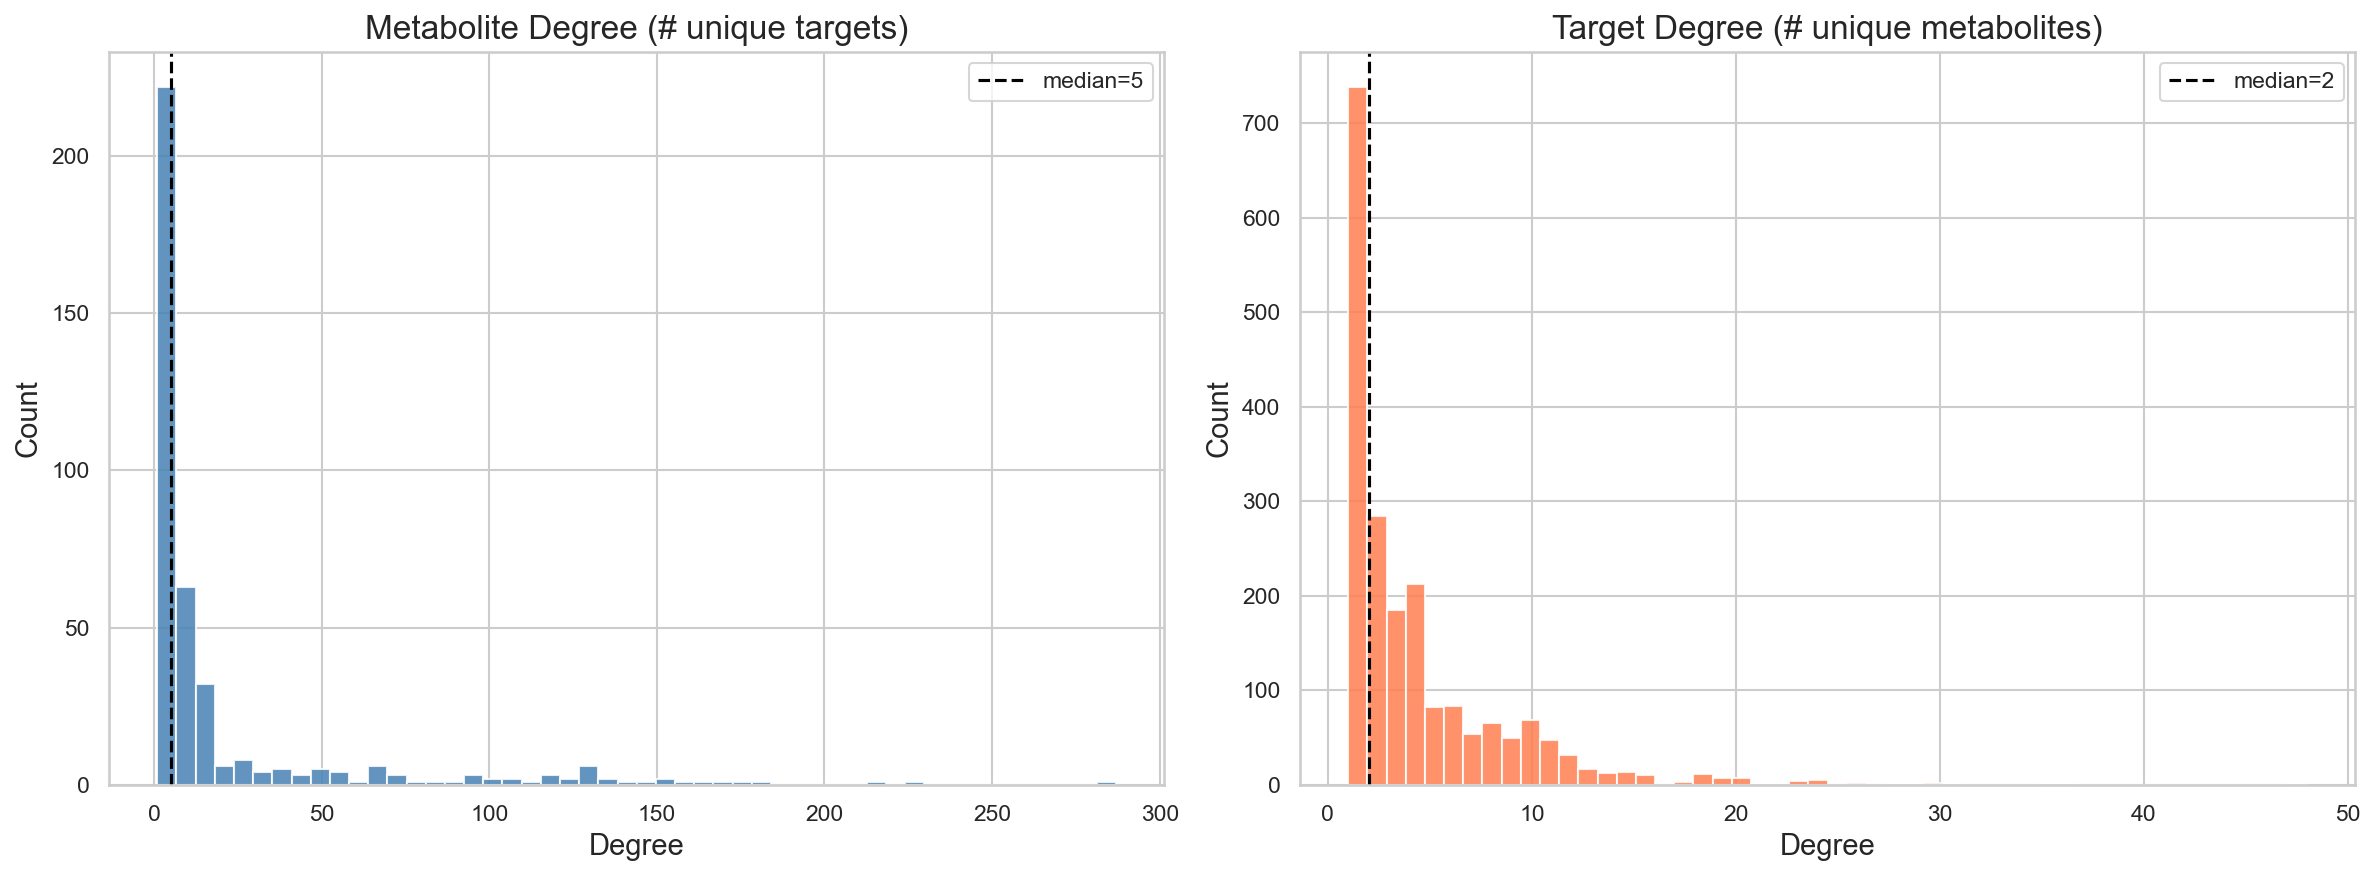

In [9]:
met_degree = df.groupby('Metabolite_Name')['Target'].nunique().sort_values(ascending=False)
tgt_degree = df.groupby('Target')['Metabolite_Name'].nunique().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, color in [(axes[0], met_degree, 'Metabolite Degree (# unique targets)', 'steelblue'),
                                (axes[1], tgt_degree, 'Target Degree (# unique metabolites)', 'coral')]:
    ax.hist(data.values, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_xlabel('Degree'); ax.set_ylabel('Count'); ax.set_title(title)
    ax.axvline(data.median(), color='black', ls='--', label=f'median={data.median():.0f}')
    ax.legend()
plt.tight_layout(); plt.show()

print(f'Metabolite degree: median={met_degree.median():.0f}, max={met_degree.max()} ({met_degree.idxmax()})')
print(f'Target degree: median={tgt_degree.median():.0f}, max={tgt_degree.max()} ({tgt_degree.idxmax()})')

### 3.2. Top 20 Hub Metabolites & Targets

### Purpose
To systematically identify the most connected signaling players (hubs) in the network. In cancer systems biology, network hubs often represent critical signaling bottlenecks, metabolic sensors, or broad-spectrum therapeutic targets.

### How to Interpret the Results
- **Top Hub Metabolites (Left Plot):** These represent high-influence signaling molecules (such as Glutamate, ATP, or Adenosine) that act as "master keys" in the TME. Targeting these or their transporters can profoundly disrupt multi-cellular tumor-stromal signaling cascades.
- **Top Hub Targets (Right Plot):** These are proteins (receptors, transporters, or enzymes) that bind a large diversity of metabolites. A target appearing at the top of this list is a master metabolic sensor (such as GPCRs or broad-spectrum solute carriers) integrating multiple microenvironmental cues to regulate cellular state.

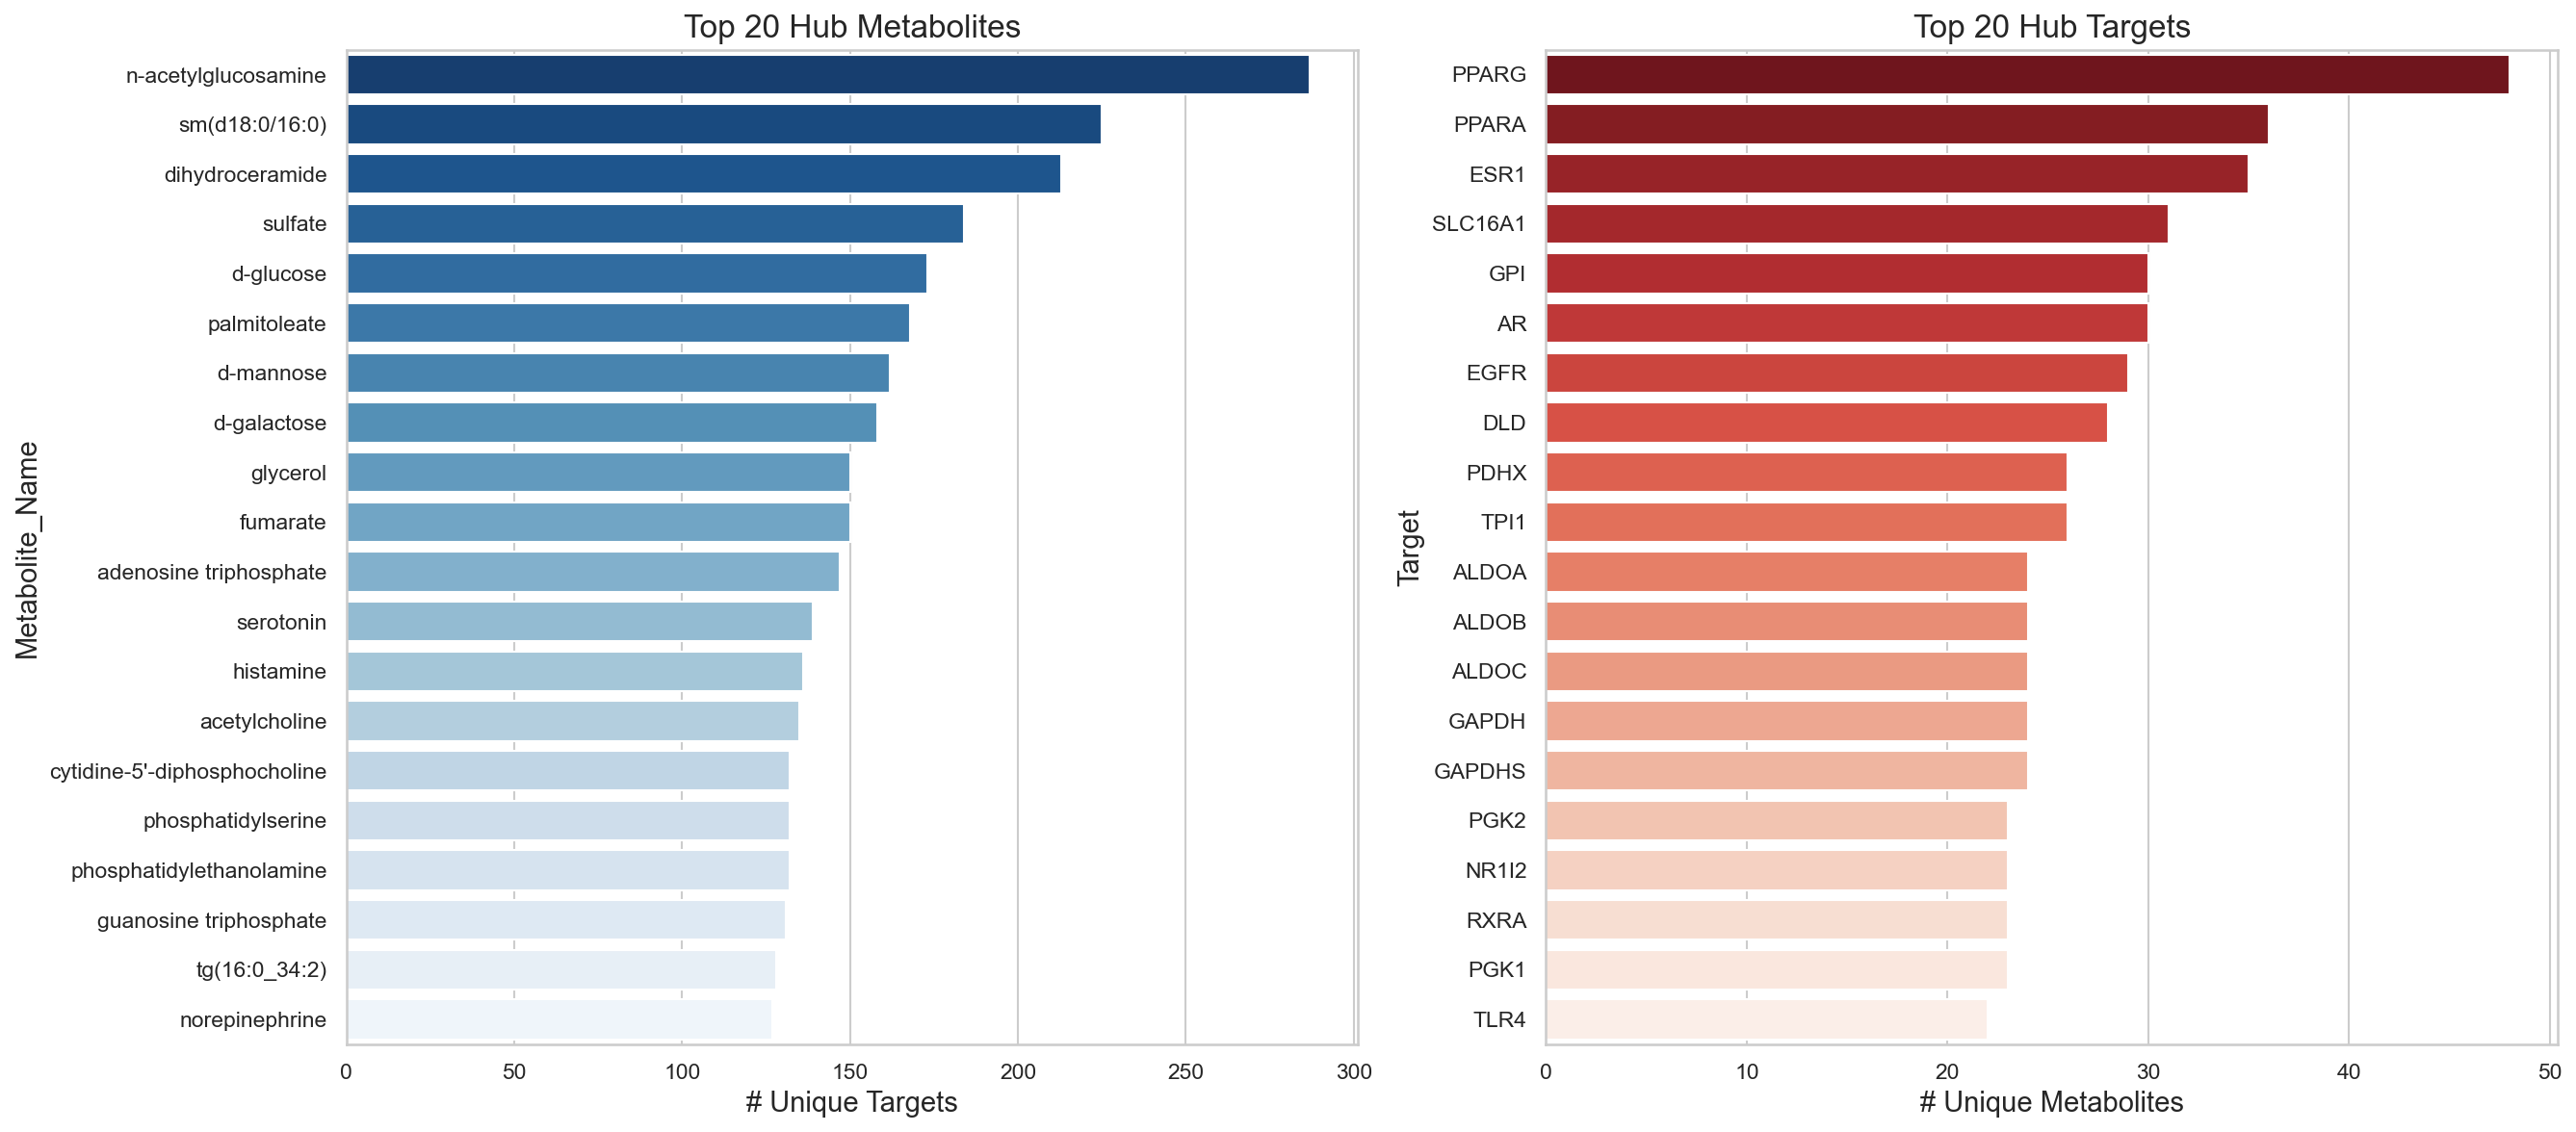

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(x=met_degree.head(20).values, y=met_degree.head(20).index, palette='Blues_r', hue=met_degree.head(20).index, legend=False, ax=axes[0])
axes[0].set_title('Top 20 Hub Metabolites'); axes[0].set_xlabel('# Unique Targets')
sns.barplot(x=tgt_degree.head(20).values, y=tgt_degree.head(20).index, palette='Reds_r', hue=tgt_degree.head(20).index, legend=False, ax=axes[1])
axes[1].set_title('Top 20 Hub Targets'); axes[1].set_xlabel('# Unique Metabolites')
plt.tight_layout(); plt.show()

---

## 4. Database Provenance & Confidence

### 4.1. Cross-Database Validation of Pairs

### Purpose
Ligand-target databases are compiled using different curation strategies, literature extraction methods, and prediction algorithms. This analysis assesses the degree of consensus across different primary databases. High database overlap serves as a proxy for empirical confidence and biological reproducibility.

### How to Interpret the Results
- **Single-Database Support:** Pairs supported by only 1 database are more likely to contain false positives or context-specific interactions.
- **Multi-Database Consensus (2+ or 3+ databases):** Represents highly validated core interactions with high biological confidence. These are the prime candidates for high-fidelity downstream modeling or wet-lab validation.


High-confidence pairs (3+ databases): 728 (8.5%)


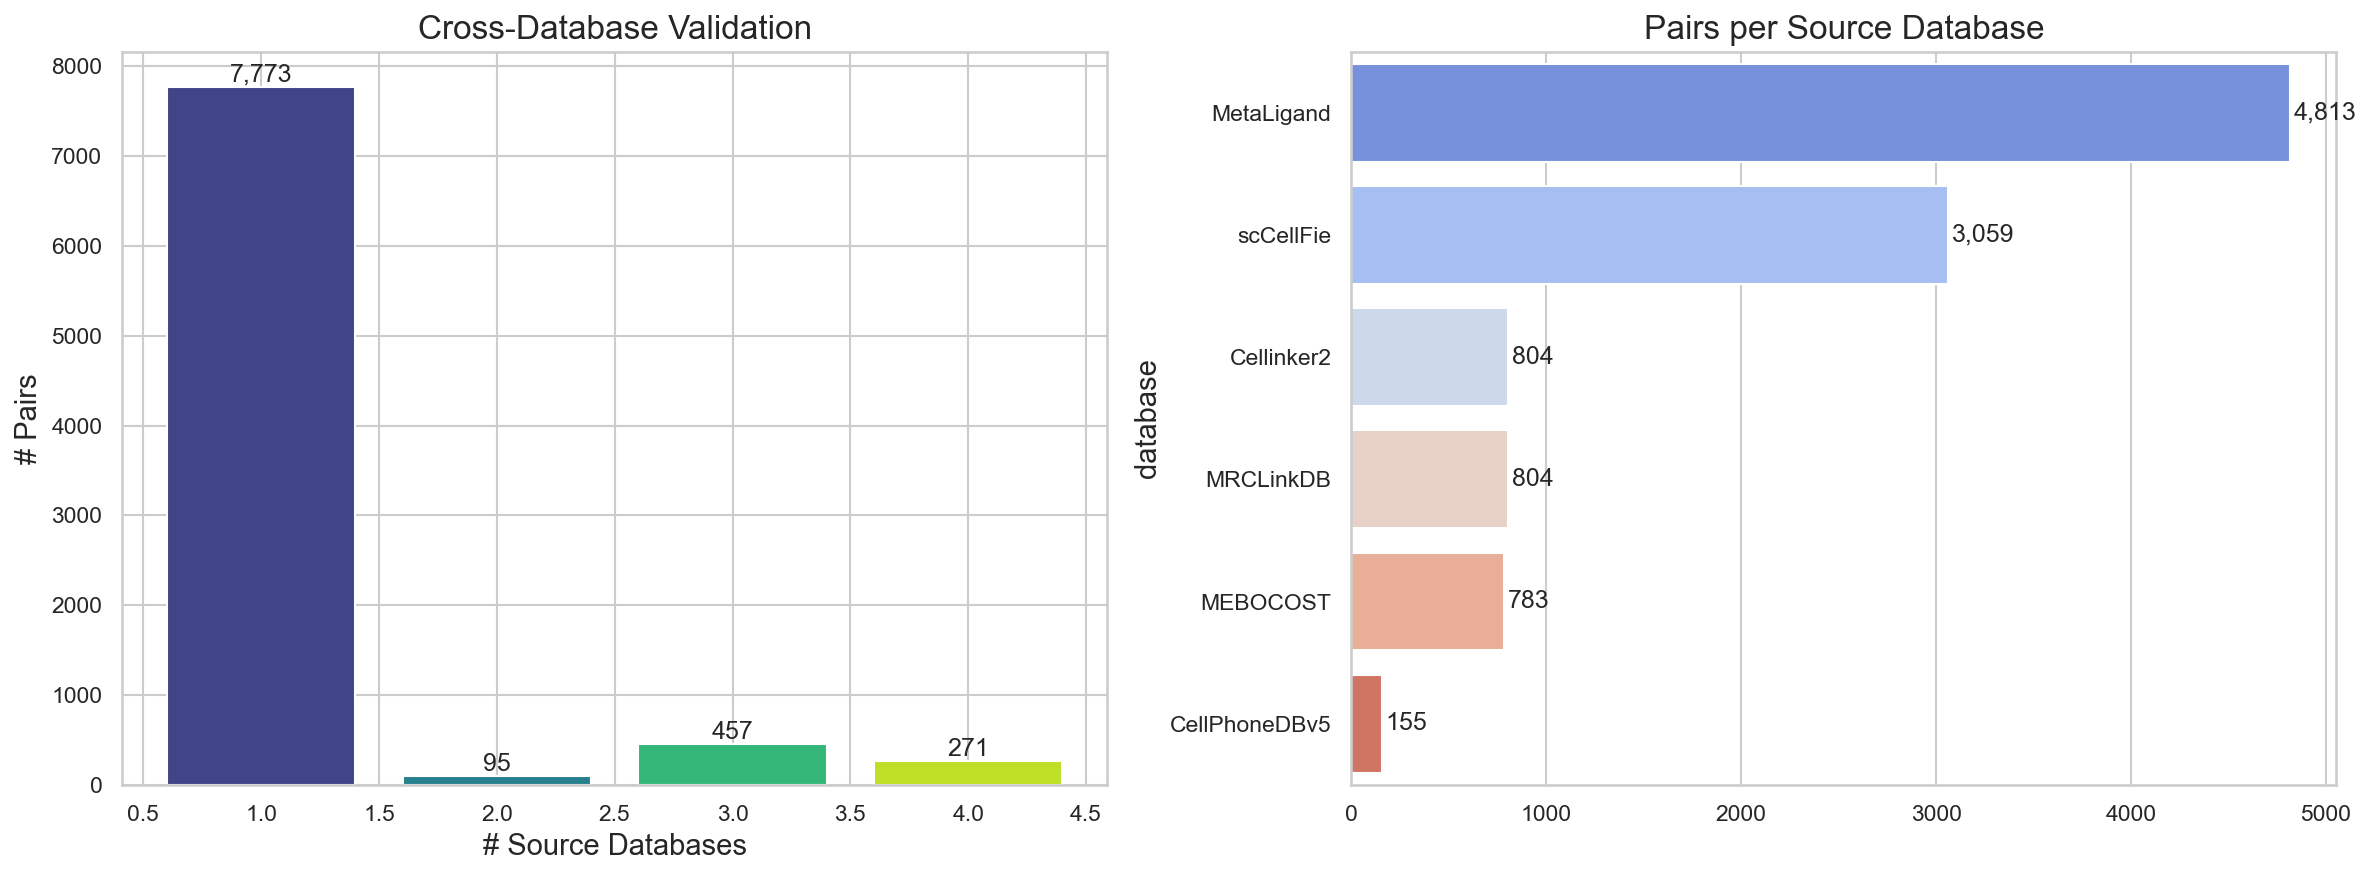

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
vc = df['databases_count'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=plt.cm.viridis(np.linspace(0.2,0.9,len(vc))), edgecolor='white')
for i, (x, y) in enumerate(zip(vc.index, vc.values)): axes[0].text(x, y, f'{y:,}', ha='center', va='bottom')
axes[0].set_xlabel('# Source Databases'); axes[0].set_ylabel('# Pairs'); axes[0].set_title('Cross-Database Validation')

db_pairs = df['database'].str.split(', ').explode().value_counts()
sns.barplot(x=db_pairs.values, y=db_pairs.index, palette='coolwarm', hue=db_pairs.index, legend=False, ax=axes[1])
axes[1].set_title('Pairs per Source Database')
for i, v in enumerate(db_pairs.values): axes[1].text(v+20, i, f'{v:,}', va='center')
plt.tight_layout(); plt.show()

print(f'\nHigh-confidence pairs (3+ databases): {(df["databases_count"]>=3).sum():,} ({(df["databases_count"]>=3).mean()*100:.1f}%)')

---

## 5. Interaction Biology

### 5.1. Sensor Type Distribution

### Purpose
To categorize the functional roles of target proteins (Receptors, Enzymes, Transporters) mediating metabolic communication. Metabolites act through distinct biological mechanisms: triggering intracellular signaling (Receptors), internalizing cargo (Transporters), or undergoing chemical processing in the TME (Enzymes).

### How to Interpret the Results
- **Receptors:** Represent direct cell-surface signaling (e.g., GPCR activation), mediating classical paracrine pathways.
- **Transporters:** Indicate direct import/export (e.g., Solute Carriers), affecting the intracellular metabolic pool of receiver cells.
- **Enzymes:** Show active enzymatic modification of the TME, representing localized, microenvironmental metabolic remodeling.

Number of NaN values (unannotated): 7,813
Percentage of missing values: 90.89%


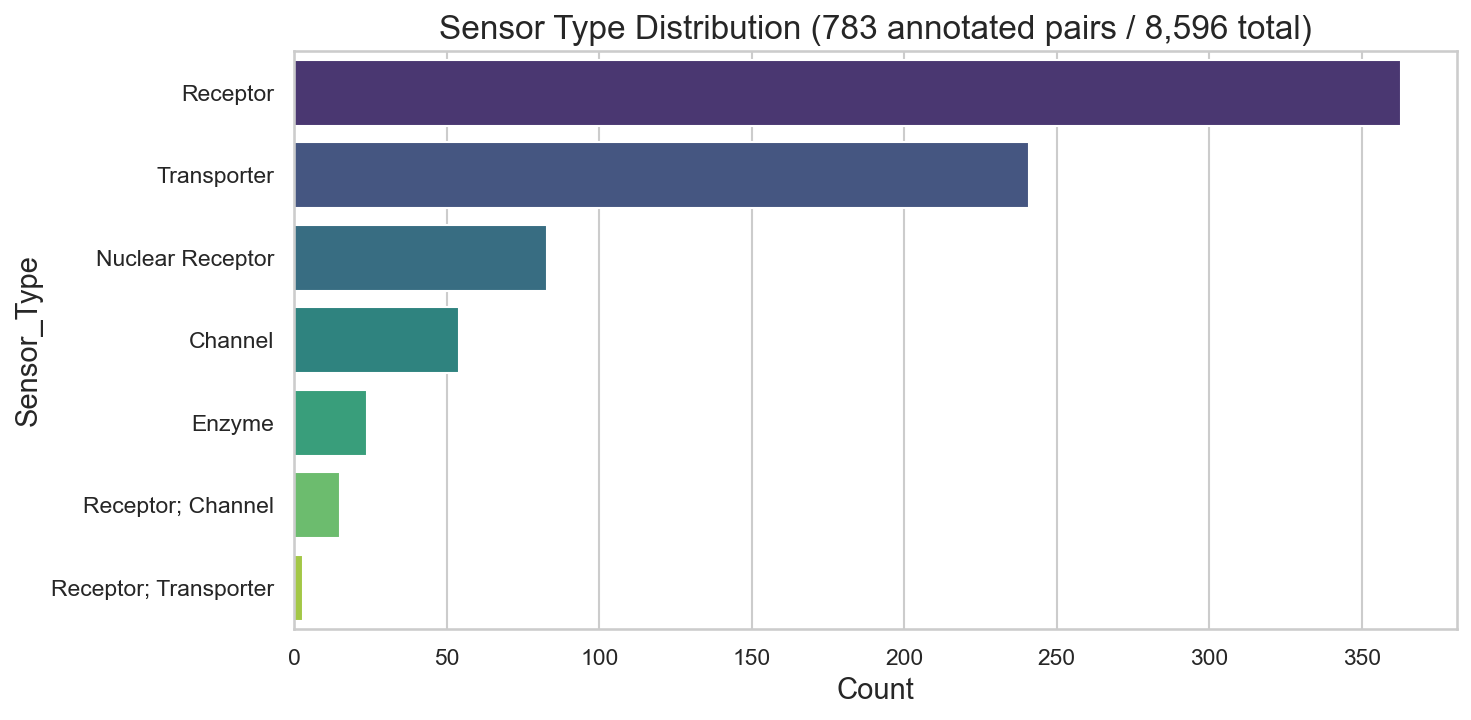

In [12]:
st = df['Sensor_Type'].value_counts(dropna=False)
nan_count = df['Sensor_Type'].isna().sum()
nan_percentage = df['Sensor_Type'].isna().mean() * 100

print(f"Number of NaN values (unannotated): {nan_count:,}")
print(f"Percentage of missing values: {nan_percentage:.2f}%")

st = df['Sensor_Type'].value_counts(dropna=True)
plt.figure(figsize=(10, 5))
sns.barplot(x=st.values, y=st.index, palette='viridis', hue=st.index, legend=False)
plt.title(f'Sensor Type Distribution ({st.sum():,} annotated pairs / {len(df):,} total)')
plt.xlabel('Count'); plt.show()

### 5.2. Enzyme Product/Substrate Relationships

### Purpose
Focuses specifically on the subset of interactions classified as "Enzymes" to determine if the target protein treats the metabolite as a **substrate** (consuming it) or a **product** (synthesizing/releasing it). This defines the localized metabolic flux in the TME.

### How to Interpret the Results
- **Substrate Dominance:** Indicates that the target cell actively consumes the metabolite, acting as a metabolic "sink" in cellular communication.
- **Product Dominance:** Indicates that the target cell actively synthesizes and secretes the metabolite, serving as a localized metabolic "source" in the microenvironment.

Number of NaN values (unannotated): 7,953
Percentage of missing values: 92.52%


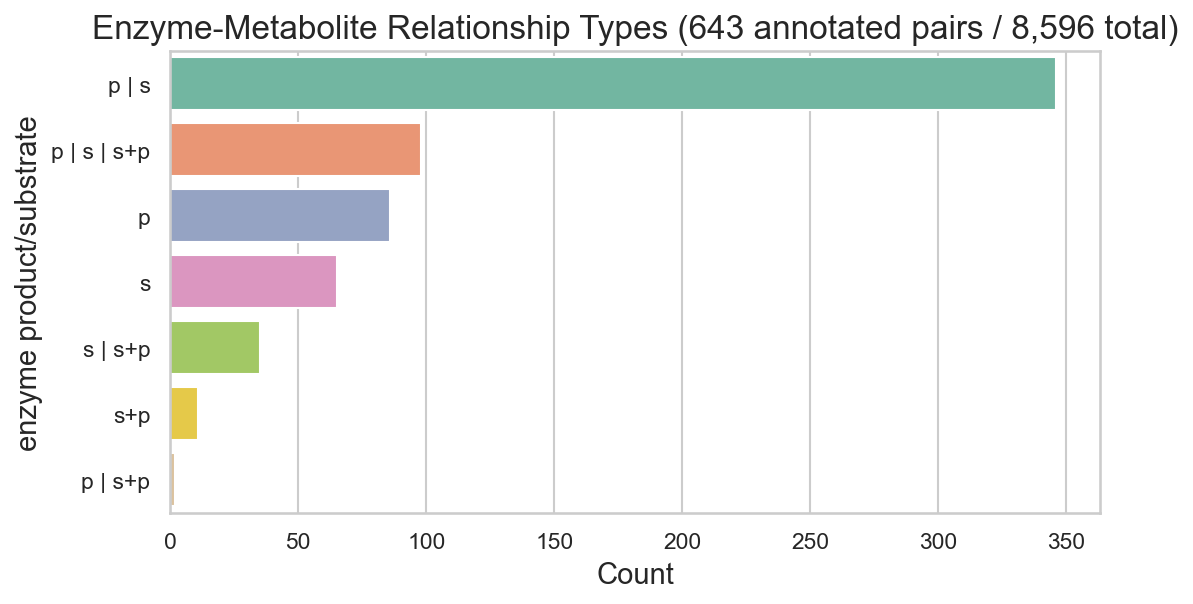

In [13]:
eps = df['enzyme product/substrate'].value_counts(dropna=False)
nan_count = df['enzyme product/substrate'].isna().sum()
nan_percentage = df['enzyme product/substrate'].isna().mean() * 100

print(f"Number of NaN values (unannotated): {nan_count:,}")
print(f"Percentage of missing values: {nan_percentage:.2f}%")

eps = df['enzyme product/substrate'].value_counts(dropna=True)
plt.figure(figsize=(8, 4))
sns.barplot(x=eps.values, y=eps.index, palette='Set2', hue=eps.index, legend=False)
plt.title(f'Enzyme-Metabolite Relationship Types ({eps.sum():,} annotated pairs / {len(df):,} total)'); plt.xlabel('Count'); plt.show()


### 5.3. Interaction Type (Promote/Inhibit/Release/Consume)

### Purpose
Beyond simple binding, this section analyzes the functional outcome of the interaction. It defines whether the metabolite-target pairing triggers activation (promote), downregulation (inhibit), secretion (release), or uptake (consume).

### How to Interpret the Results
- **Promote vs. Inhibit:** A high ratio of "Promote" interactions suggests positive signaling amplification cascades in the TME, whereas "Inhibit" interactions represent negative-feedback regulatory loops.
- **Release vs. Consume:** Directly maps the metabolic source/sink dynamics, allowing us to trace how metabolites are exchanged dynamically between cells.

Number of NaN values (unannotated): 8,133
Percentage of missing values: 94.61%


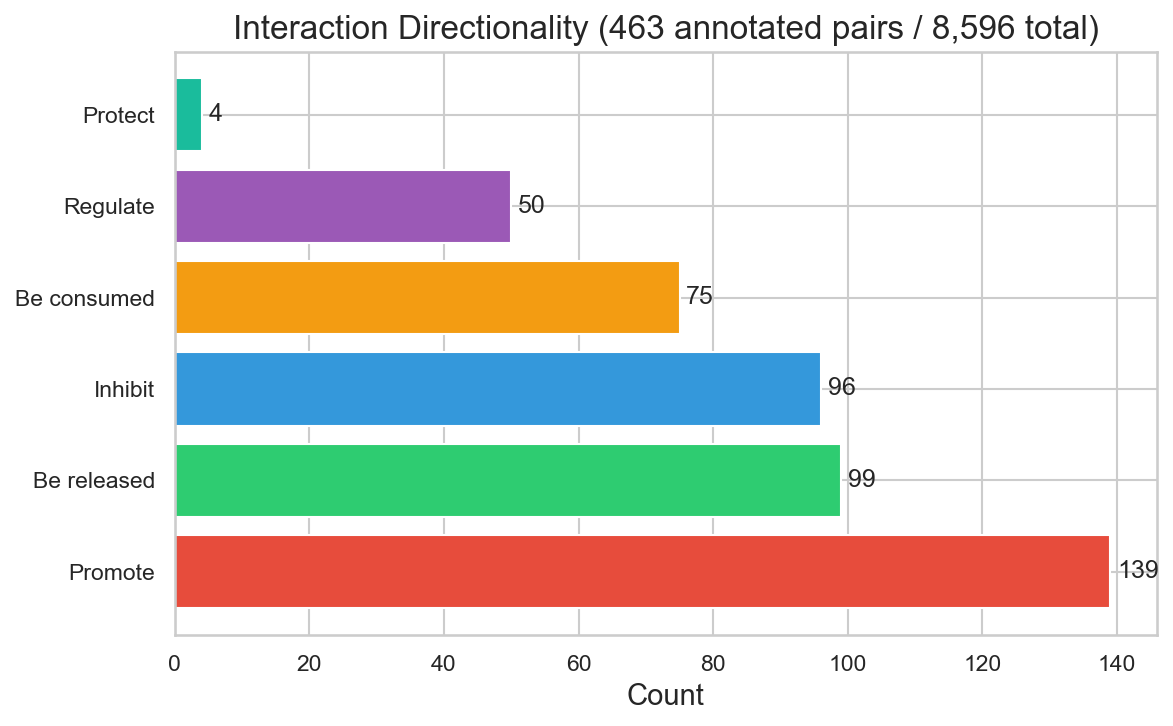

In [14]:
inter = df['Interaction'].value_counts(dropna=False)
nan_count = df['Interaction'].isna().sum()
nan_percentage = df['Interaction'].isna().mean() * 100
print(f"Number of NaN values (unannotated): {nan_count:,}")
print(f"Percentage of missing values: {nan_percentage:.2f}%")

inter = df['Interaction'].value_counts(dropna=True)
colors_int = {'Promote': '#e74c3c', 'Inhibit': '#3498db', 'Be released': '#2ecc71', 'Be consumed': '#f39c12', 'Regulate': '#9b59b6', 'Protect': '#1abc9c'}
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(inter.index, inter.values, color=[colors_int.get(i, '#95a5a6') for i in inter.index])
ax.set_xlabel('Count'); ax.set_title(f'Interaction Directionality ({inter.sum()} annotated pairs / {len(df):,} total)')
for i, v in enumerate(inter.values): ax.text(v+1, i, str(v), va='center')
plt.tight_layout(); plt.show()

---

## 6. Chemical & Metabolic Classification

### 6.1. SuperClass of Interacting Metabolites

### Purpose
To classify interacting metabolites into distinct chemical families (e.g., Lipids, Amino Acids, Carbohydrates). This reveals which chemical families dominate cell-cell communication in the TME and helps identify class-specific therapeutic strategies.

### How to Interpret the Results
- **Amino Acids & Peptides:** Typically act as rapid signaling cues and protein building blocks, vital for highly proliferative tumor environments.
- **Lipids & Lipid-like Molecules:** Often represent hydrophobic signaling cues (e.g., eicosanoids, steroid hormones) that mediate long-range or membrane-associated signaling.
- **Carbohydrates:** Reflect the core energetic demands and glycosylation signaling pathways.

Number of NaN values (unannotated): 3,570
Percentage of missing values: 41.53%


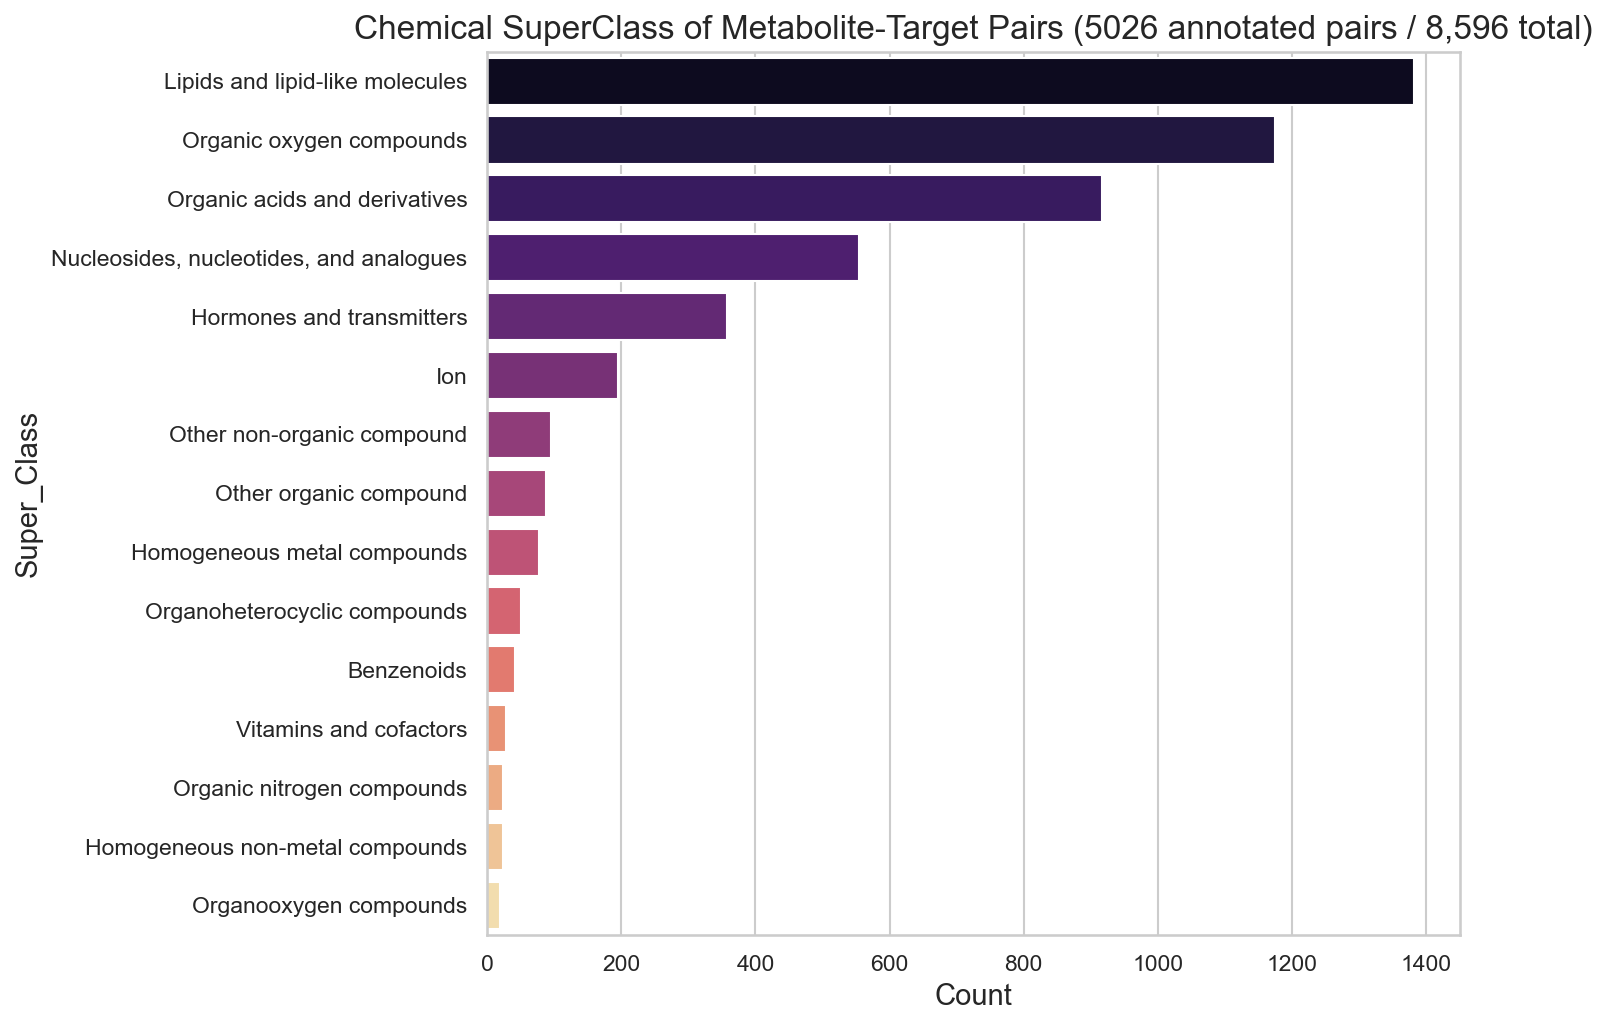

In [15]:
sc = df['Super_Class'].value_counts(dropna=False)
nan_count = df['Super_Class'].isna().sum()
nan_percentage = df['Super_Class'].isna().mean() * 100
print(f"Number of NaN values (unannotated): {nan_count:,}")
print(f"Percentage of missing values: {nan_percentage:.2f}%")



sc = df['Super_Class'].value_counts(dropna=True)
plt.figure(figsize=(10, 7))
sns.barplot(x=sc.values, y=sc.index, palette='magma', hue=sc.index, legend=False)
plt.title(f'Chemical SuperClass of Metabolite-Target Pairs ({sc.sum()} annotated pairs / {len(df):,} total)')
plt.xlabel('Count'); plt.tight_layout(); plt.show()

### 6.2. Metabolic System & Subsystem (scCellFie)

### Purpose
To map the interaction pairs to their corresponding metabolic pathways (systems and subsystems) using scCellFie annotations. This translates raw chemical names into defined biochemical processes (e.g., Glycolysis, TCA Cycle, Fatty Acid Oxidation), allowing functional pathway integration.

### How to Interpret the Results
- **Top Metabolic Systems:** Identify which global metabolic networks (e.g., energy metabolism, amino acid metabolism) are most actively hijacked or utilized for cellular communication.
- **Top Subsystems:** Provide granular pathway resolution (e.g., Glutamine metabolism vs. Alanine metabolism), which is invaluable for selecting specific pathway inhibitors.


scCellFie metabolic scores available for 3,059 pairs.


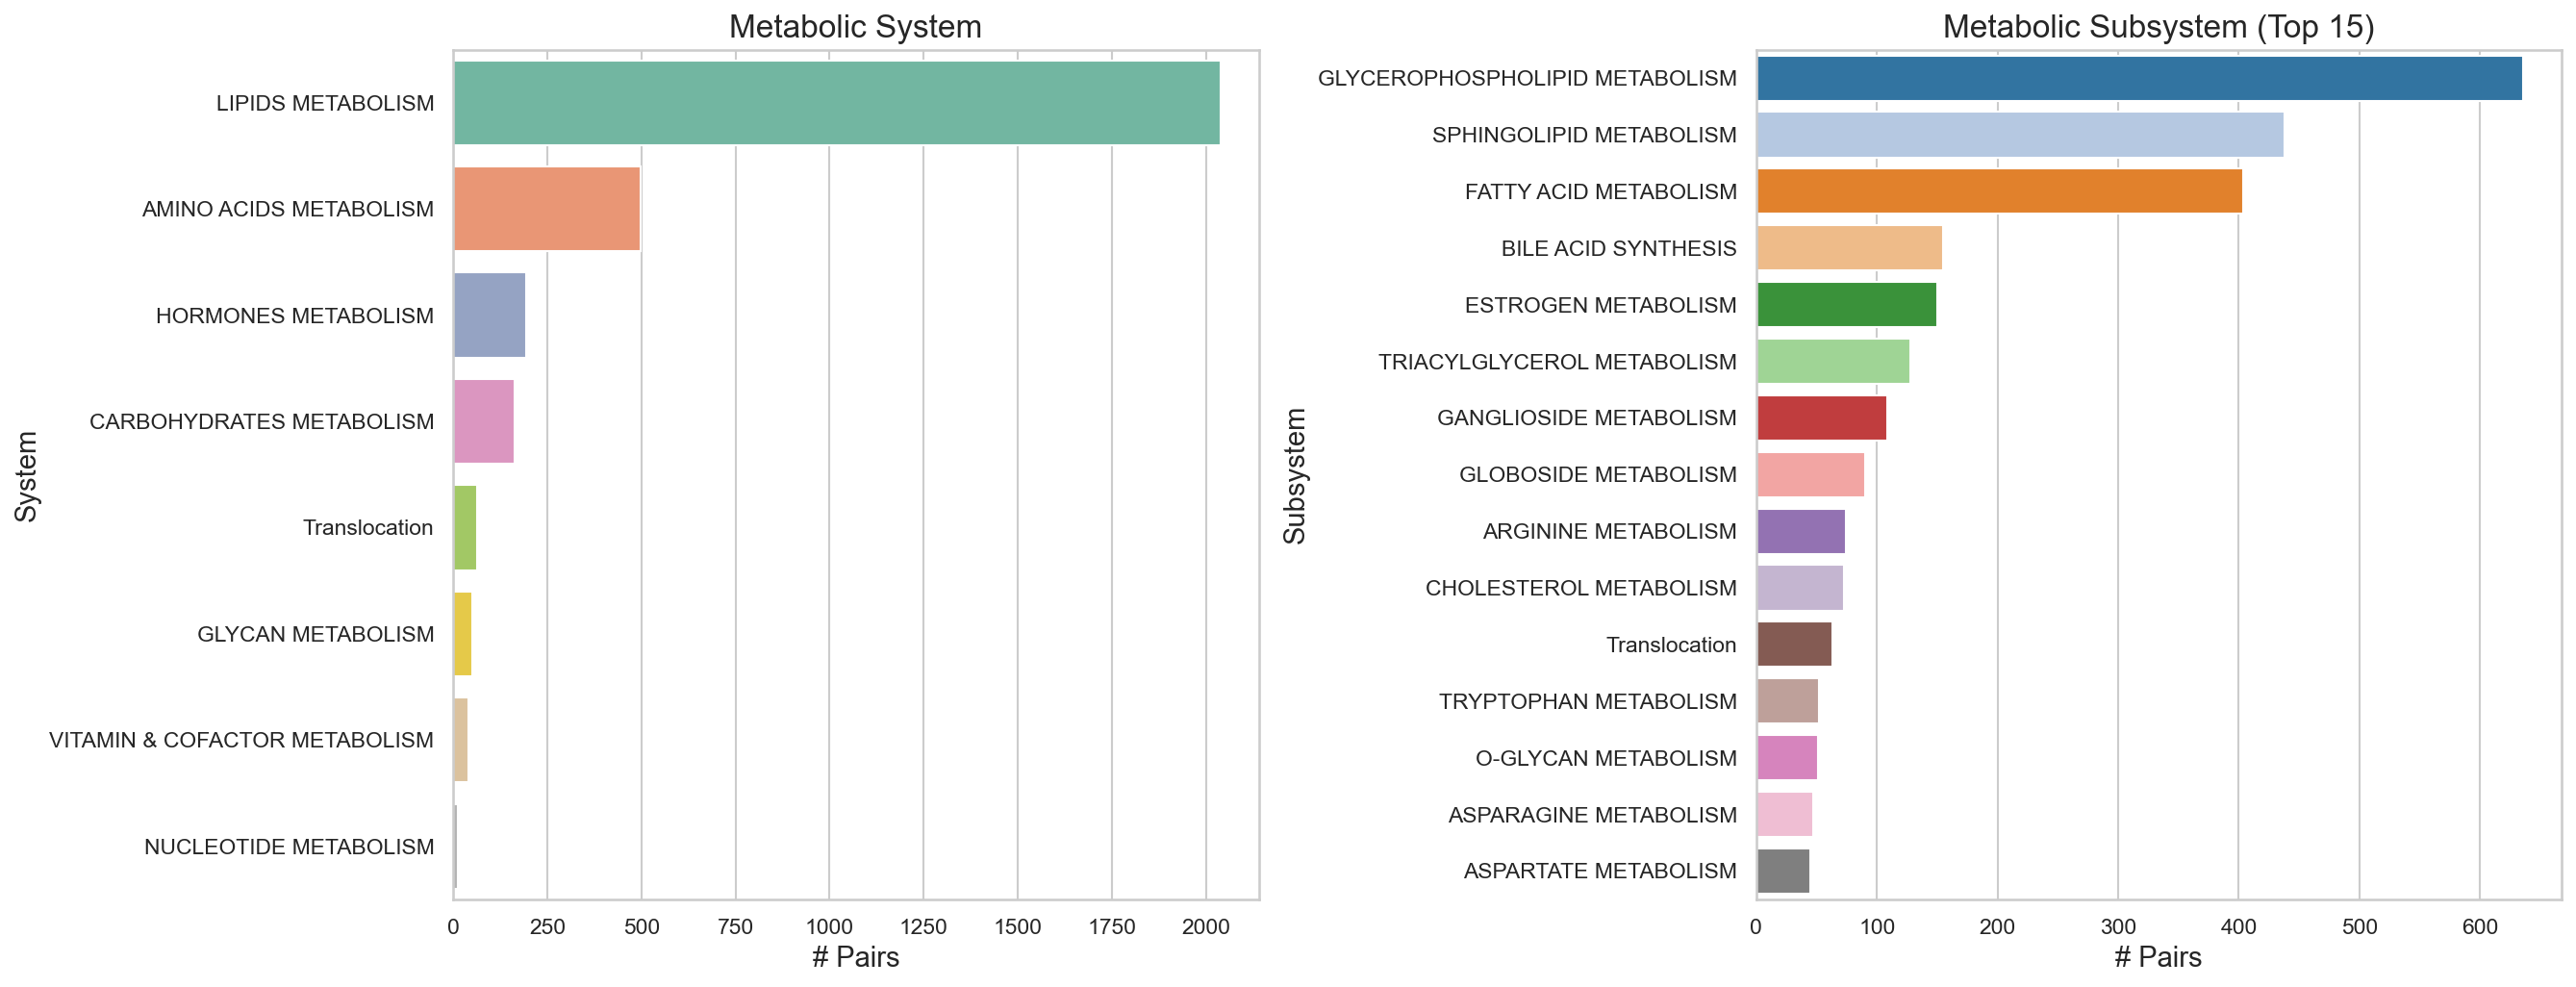

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, col, title, pal in [(axes[0], 'System', 'Metabolic System', 'Set2'), (axes[1], 'Subsystem', 'Metabolic Subsystem (Top 15)', 'tab20')]:
    vc = df[col].value_counts(dropna=True).head(15)
    sns.barplot(x=vc.values, y=vc.index, palette=pal, hue=vc.index, legend=False, ax=ax)
    ax.set_title(title); ax.set_xlabel('# Pairs')
plt.tight_layout(); plt.show()
print(f'\nscCellFie metabolic scores available for {df["scCellFie_value"].notna().sum():,} pairs.')

---

## 7. Cancer-Relevant Analysis

### 7.1. Disease Annotations

### Purpose
To map these metabolite-target interactions to clinically relevant diseases and cancer types using MRCLinkDB's expert-curated metadata. This grounds the basic biological network in real clinical oncology context.

**Data Provenance & Backtrack Info:**  
The metadata in columns `Disease`, `Cell type`, `Effect`, and `Interaction` is specific to the **MRCLinkDB** source. 

- **Source File:** `MRCLinkDB/Metabolite-cell interaction.txt`  
- **Ingestion Logic:** Handled in `scripts/merge_dbs_claude.py` within the `process_mrclinkdb()` function. The script specifically maps the clinical metadata provided by MRCLinkDB during the initial consolidation phase.  
- **Merge Strategy:** These annotations are carried through the pipeline only for pairs found in MRCLinkDB. For metabolites sourced from other databases (e.g., MEBOCOST, CellPhoneDBv5), these fields remain empty (`NaN`) as those databases do not provide clinical disease context in their raw ligand-receptor mapping.  

This backtrack ensures that any disease-specific results observed below can be directly attributed to the expert-curated interactions in the MRCLinkDB dataset.

### How to Interpret the Results
- **Disease Prevalence:** Shows which tumor types have the most highly characterized or literature-supported metabolite-target communication networks in public databases.
- **Annotated Pairs:** Allows you to filter down to interactions with known clinical relevance, focusing your downstream analysis on clinically validated targets.


→ 217 pairs have explicit cancer/tumor disease annotations.
→ Covering 52 metabolites and 160 targets.

🎉 Successfully saved 217 cancer-annotated interaction pairs to:
   -> '../output/human_metab_target_pairs_cancer_annotated.csv'


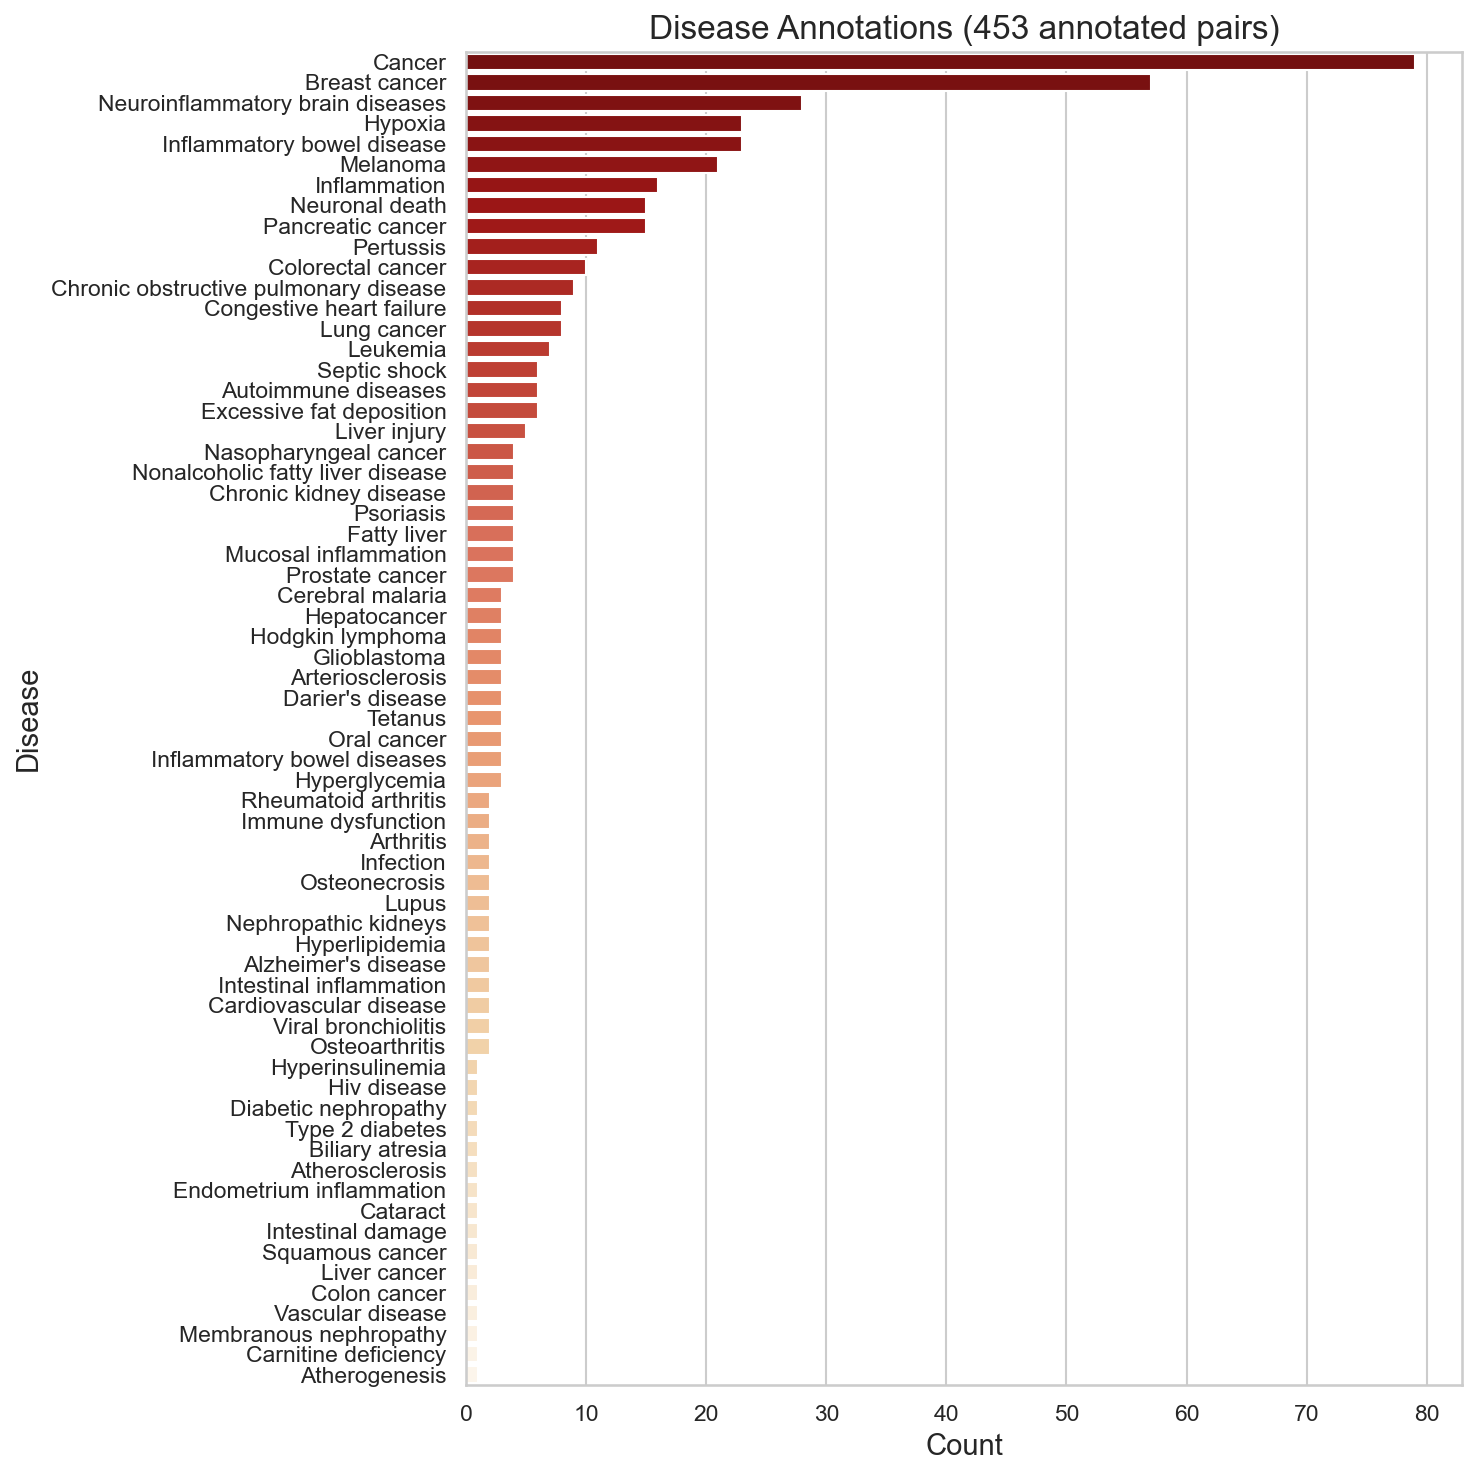

In [17]:
disease_vc = df['Disease'].value_counts(dropna=True)
plt.figure(figsize=(10, 10))
sns.barplot(x=disease_vc.values, y=disease_vc.index, palette='OrRd_r', hue=disease_vc.index, legend=False)
plt.title(f'Disease Annotations ({disease_vc.sum()} annotated pairs)'); plt.xlabel('Count')
plt.tight_layout(); plt.show()

cancer_terms = ['Cancer', 'cancer', 'carcinoma', 'Melanoma', 'melanoma', 'tumor', 'Tumor', 'leukemia', 'lymphoma']
cancer_mask = df['Disease'].str.contains('|'.join(cancer_terms), case=False, na=False)
print(f'\n→ {cancer_mask.sum()} pairs have explicit cancer/tumor disease annotations.')
print(f'→ Covering {df.loc[cancer_mask, "Metabolite_Name"].nunique()} metabolites and {df.loc[cancer_mask, "Target"].nunique()} targets.')

# ==========================================
# 💾 SAVE CANCER-ANNOTATED PAIRS WITH TIERS TO CSV
# ==========================================
df_cancer = df[cancer_mask].copy()
cancer_out_path = '../output/human_metab_target_pairs_cancer_annotated.csv'
df_cancer.to_csv(cancer_out_path, index=False)

print(f"\n🎉 Successfully saved {len(df_cancer)} cancer-annotated interaction pairs to:")
print(f"   -> '{cancer_out_path}'")

# 3. Display preview showing explicit mapping of metabolite and pair confidence tiers
df_preview = df_cancer[[
    'Metabolite_Name', 'Target', 'Disease', 'Cell type', 
    'Metabolite_Confidence_Tier', 'Pair_Confidence_Tier', 'databases_count'
]].head(15)
df_preview

### 7.2. Cell Type Annotations

### Purpose
Investigates which cell types (e.g., immune cells, cancer cells, stromal cells) are annotated as active senders or receivers for these interaction pairs. This helps reconstruct the multi-cellular cellular network of the tumor microenvironment (TME).

### How to Interpret the Results
- **Stromal-Tumor Axis:** Identifies how fibroblasts, endothelial cells, or extracellular matrix components talk to cancer cells.
- **Immune-Tumor Axis:** Pinpoints how immune cells sense metabolic shifts (e.g., T-cell suppression via lactate/adenosine) in the TME.

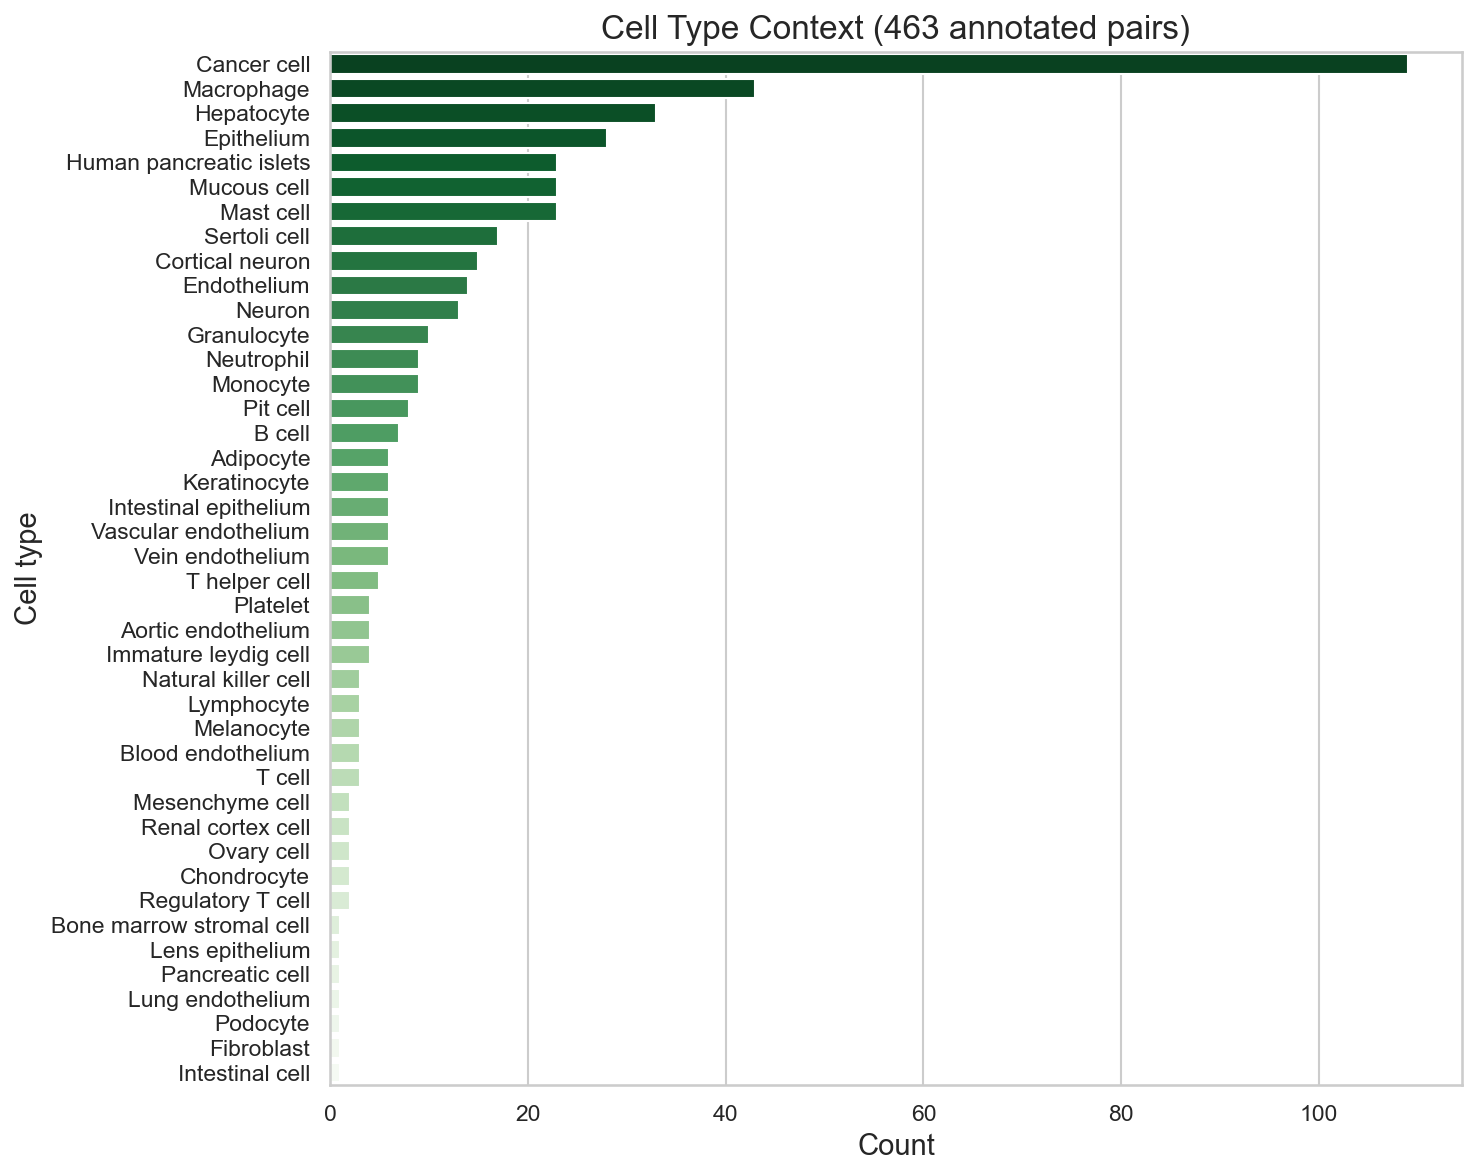

In [18]:
ct = df['Cell type'].value_counts(dropna=True)
plt.figure(figsize=(10, 8))
sns.barplot(x=ct.values, y=ct.index, palette='Greens_r', hue=ct.index, legend=False)
plt.title(f'Cell Type Context ({ct.sum()} annotated pairs)'); plt.xlabel('Count')
plt.tight_layout(); plt.show()

### 7.3. Cancer Cell Interactions: Effect & Directionality

### Purpose
To specifically isolate interactions with explicit cancer cell annotations to profile their functional outcome (e.g., promoting proliferation, inducing drug resistance, or triggering apoptosis) and directional flow.

### How to Interpret the Results
- **Pro-Tumorigenic Effects (e.g., "Promotes proliferation/metastasis"):** Ranks the key target pairs driving tumor progression, indicating high-priority therapeutic targets.
- **Immunosuppressive Directionality:** Highlights metabolite fluxes that silence cytotoxic immune cells, representing ideal targets for combination immunotherapy.


=== Top Cancer-Associated Metabolites ===
Metabolite_Name
serotonin                 23
adenosine triphosphate    20
l-glutamine               15
norepinephrine            13
d-glucose                 10
vitamin a                  8
leukotriene b4             6
l-aspartate                6
l-serine                   6
l-phenylalanine            6

=== Top Cancer-Associated Targets ===
Target
GPRC6A      7
SLC43A1     6
SLC7A5      5
SLC1A5      4
SLC16A1     3
ESR1        3
SLC43A2     3
SLC3A2      3
SLC16A10    3
AR          3


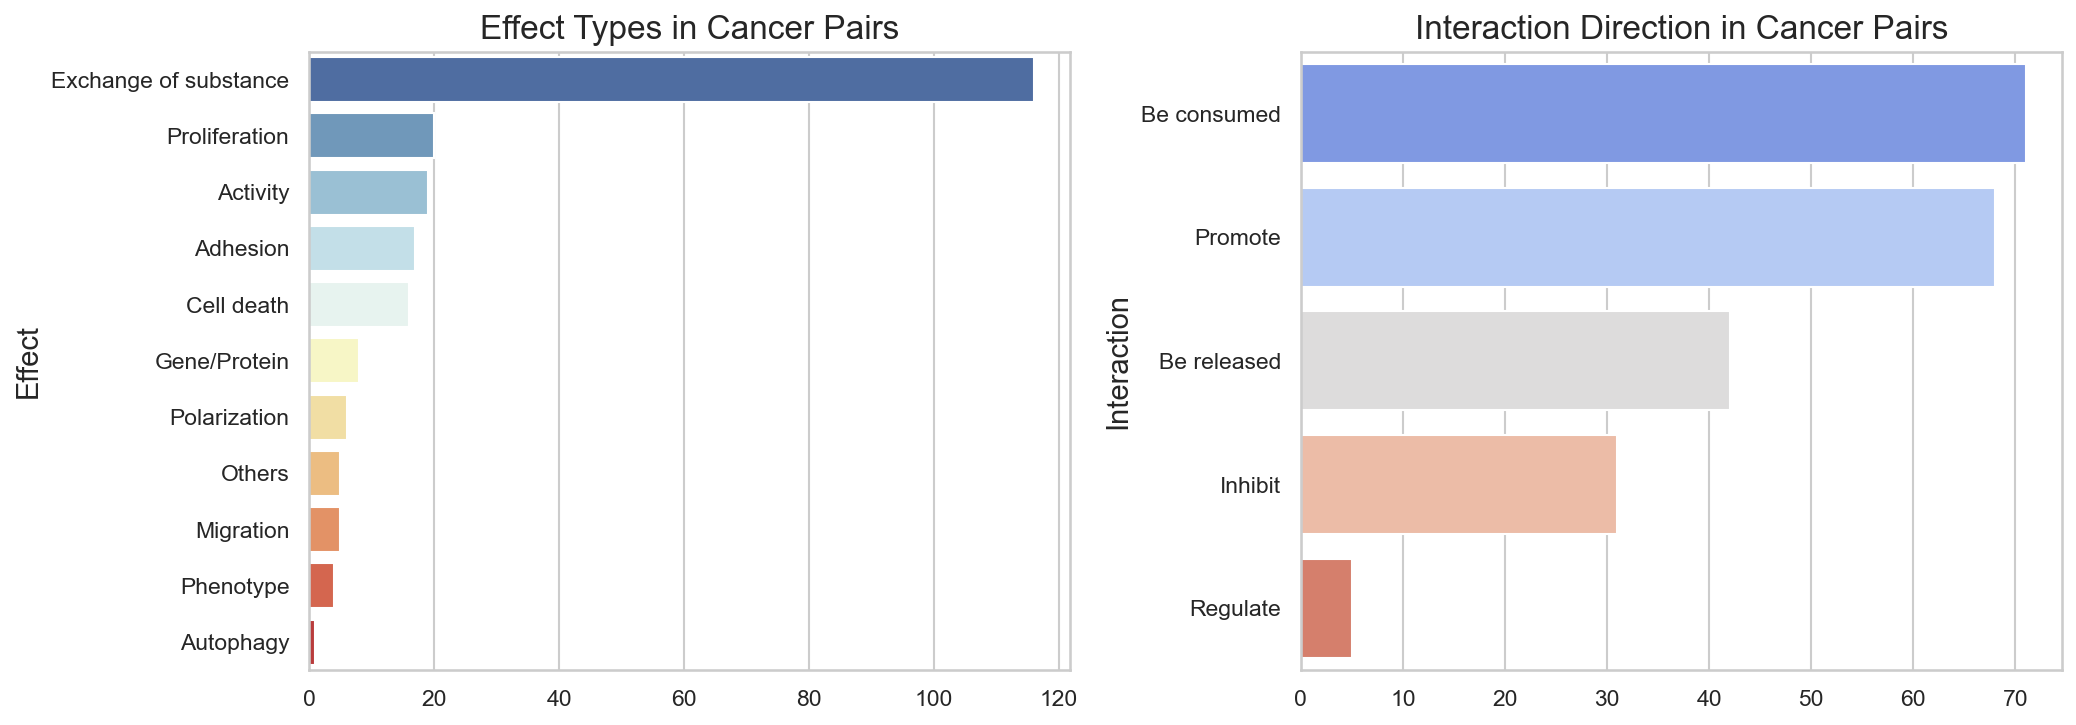

In [19]:
cancer_df = df[cancer_mask].copy()
if len(cancer_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Effect types in cancer
    eff = cancer_df['Effect'].value_counts(dropna=True)
    sns.barplot(x=eff.values, y=eff.index, palette='RdYlBu_r', hue=eff.index, legend=False, ax=axes[0])
    axes[0].set_title('Effect Types in Cancer Pairs')
    # Interaction direction in cancer
    inter_c = cancer_df['Interaction'].value_counts(dropna=True)
    if len(inter_c) > 0:
        sns.barplot(x=inter_c.values, y=inter_c.index, palette='coolwarm', hue=inter_c.index, legend=False, ax=axes[1])
    axes[1].set_title('Interaction Direction in Cancer Pairs')
    plt.tight_layout(); plt.show()

    print('\n=== Top Cancer-Associated Metabolites ===')
    print(cancer_df['Metabolite_Name'].value_counts().head(10).to_string())
    print('\n=== Top Cancer-Associated Targets ===')
    print(cancer_df['Target'].value_counts().head(10).to_string())
else:
    print('No cancer-annotated pairs found.')

---

## 8. CCC Readiness: Sender–Receiver Gene Pairs

### Purpose
For cell-cell communication scoring tools (like CellChat, SingleCellSignalR, or MEBOCOST), an interaction pair is only fully usable if we can measure both the sender cell's capacity to synthesize the metabolite (`Synthetic_genes`) and the receiver cell's capacity to sense it (`Sensor_Gene` or `Target`). This section filters and validates pairs that are fully equipped with both gene annotations.

### How to Interpret the Results
- **Dual-Gene Annotated Pairs:** These represent the most robust, computationally-ready interaction channels. They are directly ready to be merged with single-cell RNA-sequencing (scRNAseq) datasets to calculate spatial or cellular communication scores.

Total pairs: 8,596
Has sender gene (Synthetic_genes): 4,651 (54.1%)
Has receiver gene (Sensor_Gene):    783
CCC-ready pairs (sender + receiver): 4,651 (54.1%)


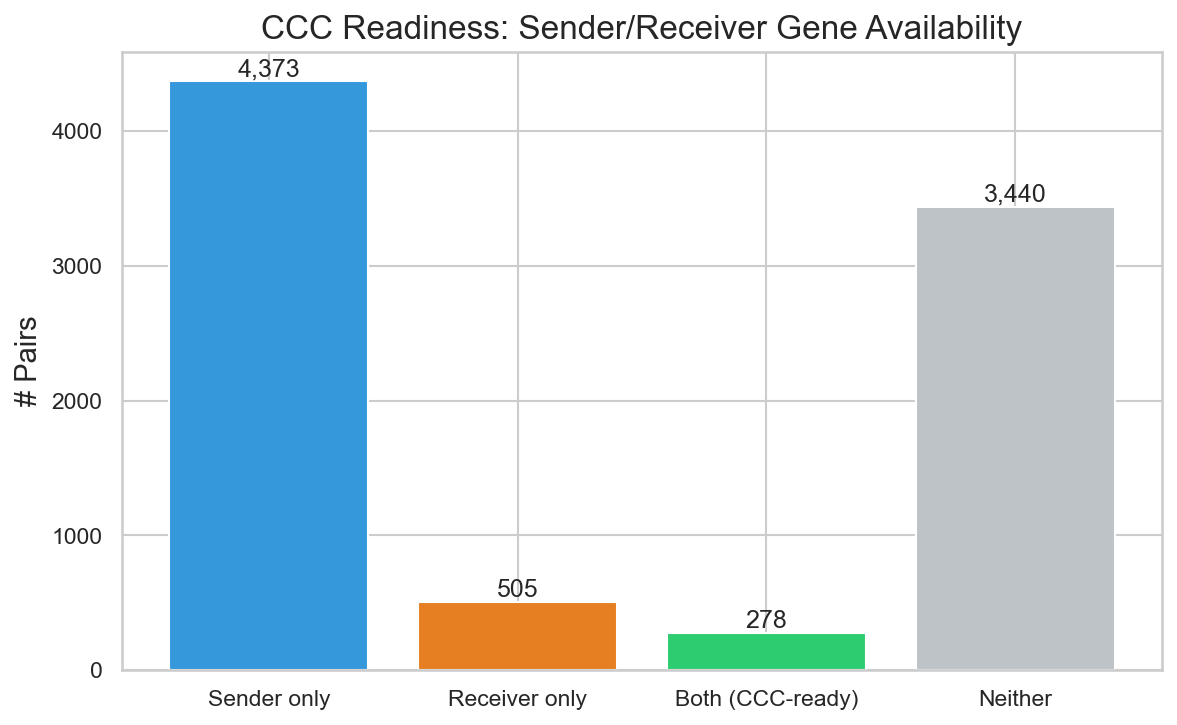

In [20]:
has_sender = df['Synthetic_genes'].notna()
has_receiver = df['Sensor_Gene'].notna() | df['Target'].notna()
ccc_ready = has_sender & has_receiver

print(f'Total pairs: {len(df):,}')
print(f'Has sender gene (Synthetic_genes): {has_sender.sum():,} ({has_sender.mean()*100:.1f}%)')
print(f'Has receiver gene (Sensor_Gene):    {df["Sensor_Gene"].notna().sum():,}')
print(f'CCC-ready pairs (sender + receiver): {ccc_ready.sum():,} ({ccc_ready.mean()*100:.1f}%)')

# Venn-like summary
fig, ax = plt.subplots(figsize=(8, 5))
cats = ['Sender only', 'Receiver only', 'Both (CCC-ready)', 'Neither']
vals = [
    (has_sender & ~df['Sensor_Gene'].notna()).sum(),
    (~has_sender & df['Sensor_Gene'].notna()).sum(),
    (has_sender & df['Sensor_Gene'].notna()).sum(),
    (~has_sender & ~df['Sensor_Gene'].notna()).sum()
]
colors_v = ['#3498db', '#e67e22', '#2ecc71', '#bdc3c7']
ax.bar(cats, vals, color=colors_v)
for i, v in enumerate(vals): ax.text(i, v, f'{v:,}', ha='center', va='bottom')
ax.set_ylabel('# Pairs'); ax.set_title('CCC Readiness: Sender/Receiver Gene Availability')
plt.tight_layout(); plt.show()

---

## 9. High-Confidence Multi-DB Pairs

### Purpose
Integrates the filters (consensus across 3+ databases AND complete gene annotations) to isolate a highly curated, ultra-high-confidence catalog of metabolic communication links.

### How to Interpret the Results
- **High-Confidence Subset:** These are your prime biological targets. They represent the "gold standard" interactions where the databases fully agree on the molecules involved, and the genetic architecture is completely characterized.

In [21]:
hc = df[(df['databases_count'] >= 3) & ccc_ready].copy()
print(f'High-confidence CCC-ready pairs: {len(hc):,}')
print(f'  Unique metabolites: {hc["Metabolite_Name"].nunique()}')
print(f'  Unique targets: {hc["Target"].nunique()}')

if len(hc) > 0:
    print('\n=== Top Metabolites in High-Confidence Set ===')
    print(hc['Metabolite_Name'].value_counts().head(15).to_string())
    print('\n=== Top Targets in High-Confidence Set ===')
    print(hc['Target'].value_counts().head(15).to_string())

High-confidence CCC-ready pairs: 264
  Unique metabolites: 79
  Unique targets: 194

=== Top Metabolites in High-Confidence Set ===
Metabolite_Name
l-glutamate                25
acetylcholine              21
adenosine triphosphate     19
serotonin                  19
gamma-aminobutyric acid    14
sphingosine 1-phosphate     9
glycine                     9
norepinephrine              8
epinephrine                 8
dopamine                    5
cyclic gmp                  5
cholesterol                 4
histamine                   4
anandamide                  4
uridine triphosphate        4

=== Top Targets in High-Confidence Set ===
Target
ESR1      5
GPRC6A    4
FFAR4     4
GPR17     4
GRIN2D    3
GRIN2A    3
NR3C2     3
GRIN1     3
TRPM2     3
TAAR1     3
P2RY14    3
NR3C1     3
NR1H3     3
GRIN2C    3
RXRG      3


---

## 10. Target Gene Lists for Downstream Integration

### Purpose
To extract the clean, unique lists of target genes (Receptors, Solute Carriers, Enzymes) that mediate these high-confidence interactions. These gene lists are ready to be integrated with clinical databases (like TCGA or GEO) to run survival analyses or expression lookups.

### How to Interpret the Results
- **Gene Lists:** These lists represent your target library. High expression of receptor genes in patient samples can be correlated with survival outcomes or drug responsiveness.

In [22]:
# All unique target genes
all_targets = df['Target'].dropna().unique()
print(f'All unique target genes: {len(all_targets)}')

# Sender genes
sender_genes = df['Synthetic_genes'].dropna().str.split(',').explode().str.strip().unique()
print(f'All unique sender genes: {len(sender_genes)}')

# Sensor genes
sensor_genes = df['Sensor_Gene'].dropna().unique()
print(f'All unique sensor genes: {len(sensor_genes)}')

# Save for downstream
os.makedirs('../output/gene_lists', exist_ok=True)
pd.Series(all_targets).to_csv('../output/gene_lists/all_target_genes.txt', index=False, header=False)
pd.Series(sender_genes).to_csv('../output/gene_lists/sender_genes.txt', index=False, header=False)
pd.Series(sensor_genes).to_csv('../output/gene_lists/sensor_genes.txt', index=False, header=False)
print('\n→ Gene lists saved to output/gene_lists/ for TCGA/GEO queries.')

All unique target genes: 2007
All unique sender genes: 2053
All unique sensor genes: 413

→ Gene lists saved to output/gene_lists/ for TCGA/GEO queries.


---

## 11. Summary Statistics

### Purpose
Provides a high-level statistical scorecard summarizing the dataset size, average degree, and confidence tier breakdown.

### How to Interpret the Results
- **Consensus Metrics:** Serves as a reference card for scientific publications or presentations, summarizing the structural properties of your consolidated network.

In [23]:
summary = {
    'Total interaction pairs': f'{len(df):,}',
    'Unique HMDB metabolites': df['HMDB_ID'].nunique(),
        'Unique metabolite names': df['Metabolite_Name'].nunique(),
    'Unique targets': df['Target'].nunique(),
    'Cancer-annotated pairs': cancer_mask.sum(),
    'CCC-ready pairs (sender+receiver)': ccc_ready.sum(),
    'High-conf CCC-ready (3+ DB)': len(hc),
    'With Sensor_Type annotation': df['Sensor_Type'].notna().sum(),
    'With Disease annotation': df['Disease'].notna().sum(),
    'With scCellFie score': df['scCellFie_value'].notna().sum(),
    'With Evidence_Score': df['Evidence_Score'].notna().sum(),
}
pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])

---

## 12. Export Full Notebook Report to HTML

Compiling this entire interactive notebook—including all structured explanations, executable code blocks, data tables, and high-resolution plots—into a single publication-ready and highly interactive HTML report.

In [24]:
# ==========================================
# 📄 FULL NOTEBOOK HTML REPORT EXPORT
# ==========================================
if 'SAVE_AS_HTML' in globals() and SAVE_AS_HTML:
    import subprocess
    import os
    
    notebook_filename = 'metab_targetPair_analysis.ipynb'
    output_html = '../output/metab_targetPair_analysis_full_report_'+TIER_FILTER+'.html'
    
    print(f"Executing full notebook HTML export for '{notebook_filename}'...")
    
    # Export to beautiful styled HTML
    print("Generating gorgeous, styling-preserved HTML report...")
    cmd_html = [
        'jupyter', 'nbconvert', '--to', 'html', 
        notebook_filename, '--output', output_html
    ]
    res_html = subprocess.run(cmd_html, capture_output=True, text=True)
    
    if res_html.returncode == 0:
        print(f"🎉 SUCCESS: Notebook successfully exported as a styled HTML report!")
        print(f"   -> Saved to: '{output_html}'")
        print("\n💡 Tip: You can open this HTML file in any web browser to view, share, or print to PDF (Cmd+P)!")
    else:
        print("❌ HTML export failed. Error details:")
        print(res_html.stderr)
else:
    print("Full notebook HTML export is currently disabled. Set SAVE_AS_HTML = True in parameters at the top to compile the report!")

Executing full notebook HTML export for 'metab_targetPair_analysis.ipynb'...
Generating gorgeous, styling-preserved HTML report...
❌ HTML export failed. Error details:
Traceback (most recent call last):
  File "/Users/sakuramaezono/miniconda3/bin/jupyter-nbconvert", line 5, in <module>
    from nbconvert.nbconvertapp import main
ModuleNotFoundError: No module named 'nbconvert'

